链接：https://blog.csdn.net/shizheng_Li/article/details/145947974

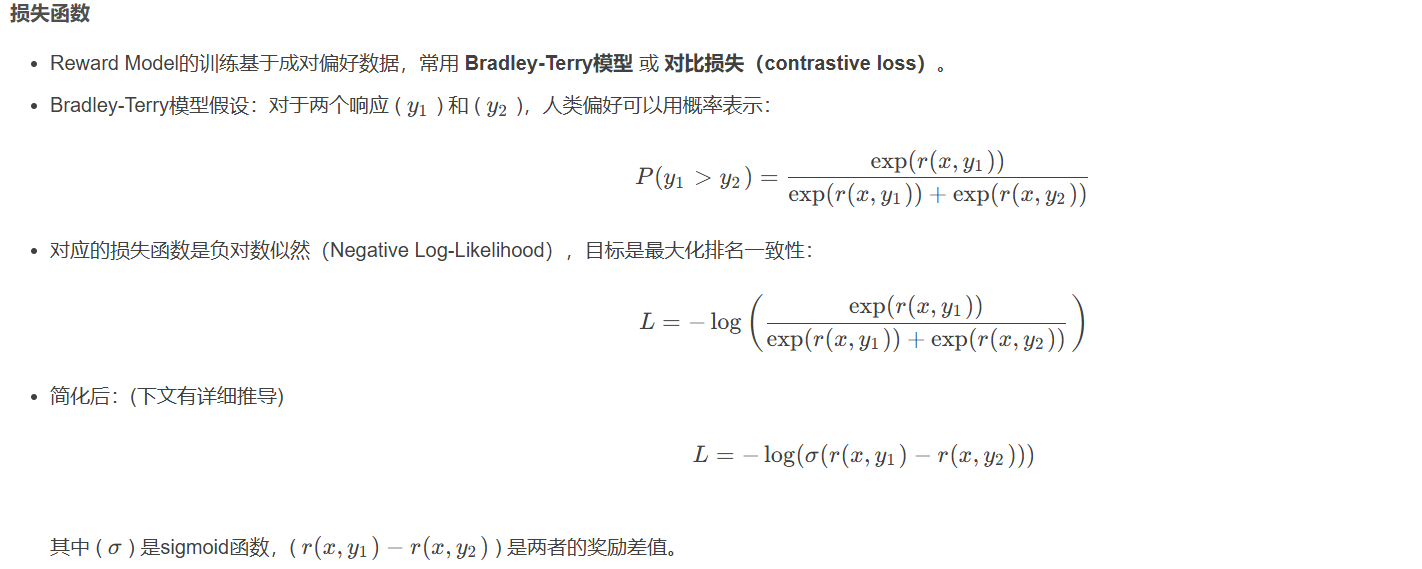

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

# 超参数
vocab_size = 1000  # 词汇表大小
embed_size = 64    # 词嵌入维度
num_heads = 4      # 多头注意力头数
hidden_size = 128  # 前馈网络隐藏层大小
num_layers = 2     # Transformer层数
max_seq_len = 10   # 最大序列长度

In [6]:
# Transformer块
class TransformerBlock(nn.Module):
    def __init__(self, embed_size, num_heads, hidden_size, dropout=0.1):
        super(TransformerBlock, self).__init__()
        self.attention = nn.MultiheadAttention(embed_size, num_heads, dropout=dropout)
        self.norm1 = nn.LayerNorm(embed_size)
        self.ffn = nn.Sequential(
            nn.Linear(embed_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, embed_size)
        )
        self.norm2 = nn.LayerNorm(embed_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_output, _ = self.attention(x, x, x, attn_mask=mask)
        x = self.norm1(x + self.dropout(attn_output))
        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_output))
        return x

In [7]:
# SFT模型（基础语言模型）
class SFTModel(nn.Module):
    def __init__(self, vocab_size, embed_size, num_heads, hidden_size, num_layers):
        super(SFTModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.pos_embedding = nn.Embedding(max_seq_len, embed_size)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_size, num_heads, hidden_size)
            for _ in range(num_layers)
        ])
        self.output_layer = nn.Linear(embed_size, vocab_size)

    def forward(self, x, mask=None):
        batch_size, seq_len = x.size()
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        x = self.embedding(x) + self.pos_embedding(positions)
        for transformer_block in self.transformer_blocks:
            x = transformer_block(x, mask)
        logits = self.output_layer(x)
        return logits

In [8]:
# Reward Model（基于SFT模型）
class RewardModel(nn.Module):
    def __init__(self, sft_model):
        super(RewardModel, self).__init__()
        self.embedding = sft_model.embedding
        self.pos_embedding = sft_model.pos_embedding
        self.transformer_blocks = sft_model.transformer_blocks
        # 替换输出层为回归层
        self.reward_head = nn.Linear(embed_size, 1)

    def forward(self, x, mask=None):
        batch_size, seq_len = x.size()
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        x = self.embedding(x) + self.pos_embedding(positions)
        for transformer_block in self.transformer_blocks:
            x = transformer_block(x, mask)
        # 取最后一个位置的隐藏状态（或平均池化）
        x = x[:, -1, :]  # [batch_size, embed_size]
        reward = self.reward_head(x)  # [batch_size, 1]
        return reward

In [ ]:
# 训练Reward Model
def train_reward_model(reward_model, data_pairs, epochs=10):
    optimizer = optim.Adam(reward_model.parameters(), lr=0.001)
    criterion = nn.BCEWithLogitsLoss()  # 二分类损失，用于偏好对比

    for epoch in range(epochs):
        total_loss = 0
        for prompt, response_better, response_worse in data_pairs:
            # 转换为张量
            prompt = torch.tensor(prompt, dtype=torch.long).unsqueeze(0).to(device)
            response_better = torch.tensor(response_better, dtype=torch.long).unsqueeze(0).to(device)
            response_worse = torch.tensor(response_worse, dtype=torch.long).unsqueeze(0).to(device)

            # 计算奖励
            r_better = reward_model(response_better)
            r_worse = reward_model(response_worse)

            # 偏好损失：r_better > r_worse
            logits = r_better - r_worse  # 差值作为logits
            target = torch.ones_like(logits)  # 目标是1，表示better优于worse
            # BCEWithLogitsLoss(logits,target)=−[target⋅log(σ(logits))+(1−target)⋅log(1−σ(logits))] 
            # 即 ( −log⁡(σ(logits))
            loss = criterion(logits, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}, Loss: {total_loss / len(data_pairs)}")


In [14]:
# 示例数据：(prompt, better_response, worse_response)
data_pairs = [
    ([0], [1, 2, 3], [1, 4, 5]),  # 假设[1, 2, 3]优于[1, 4, 5]
    ([1], [2, 3, 4], [2, 5, 6]),
]

# 初始化并训练
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sft_model = SFTModel(vocab_size, embed_size, num_heads, hidden_size, num_layers).to(device)
reward_model = RewardModel(sft_model).to(device)
train_reward_model(reward_model, data_pairs)

Epoch 1, Loss: 1.1286635994911194
Epoch 2, Loss: 0.7178758382797241
Epoch 3, Loss: 0.5024837106466293
Epoch 4, Loss: 0.291828989982605
Epoch 5, Loss: 0.1535884588956833
Epoch 6, Loss: 0.10491250827908516
Epoch 7, Loss: 0.07106184586882591
Epoch 8, Loss: 0.03708664886653423
Epoch 9, Loss: 0.02747916802763939
Epoch 10, Loss: 0.014188433531671762
